In [ ]:
!pip install ipython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.3 MB/s eta 0:00:00


# Step-1: load the images

- we can load the images in 3 ways

- using opnecv

    - when we apply opencv cv2.imread it will load as **pixels**

    - again we need to **show** seperetely

- using pillow

    - when we apply pillow  Image.open , it will load as directly imge

- using keras

    - when we apply keras preprocess load image, directly load as image only


## Using Opencv

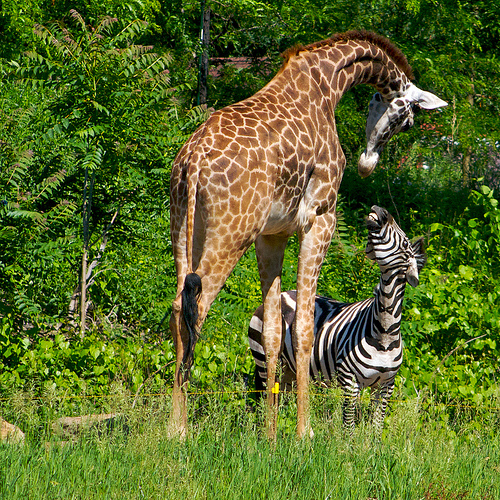

In [ ]:
from google.colab.patches import cv2_imshow
import cv2
img=cv2.imread("/content/giraffe.jpg")  # Direct as pixels
cv2_imshow(img)

## Using pillow

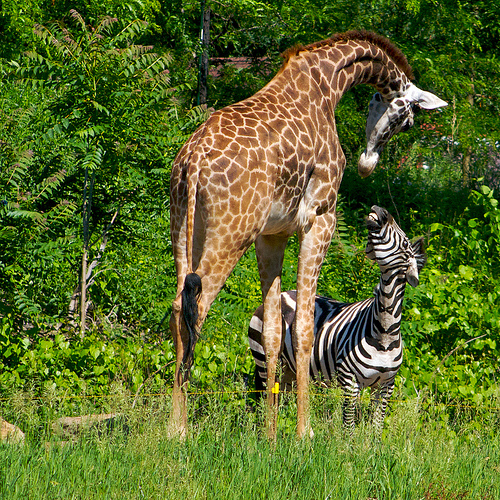

In [ ]:
from PIL import Image
img=Image.open("/content/giraffe.jpg") # Direct as image
img

## If want to show axis level

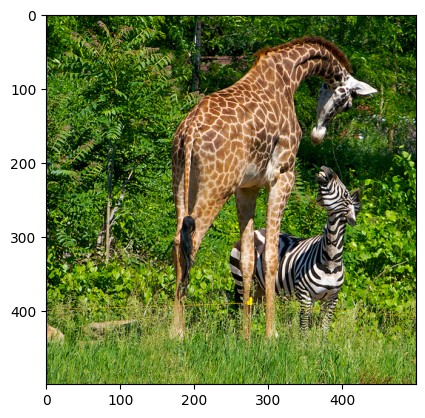

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(img)

## Using keras

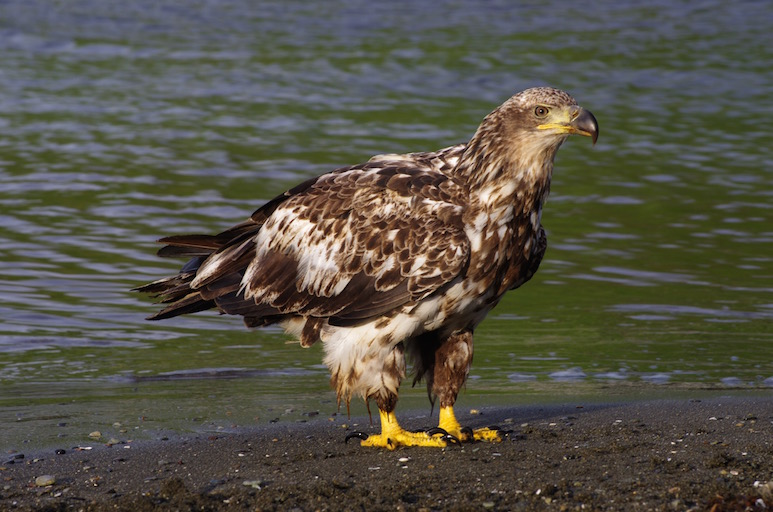

In [28]:

from keras.preprocessing import image
import numpy as np
# Mobile net input shape is (224,224)
img = image.load_img('/content/eagle.jpg')
img

## Ipython display

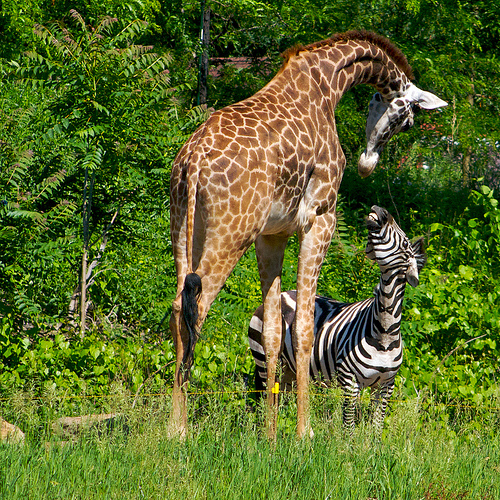

In [29]:
from IPython.display import display, Image
img = Image(filename='/content/giraffe.jpg')
display(img)

- Step1: load the image
    - Mobilenet input shape of image is 224,224
    - So load the image with target szie of 224,224

- Step-2: read the mobilnet model

- Step-3: read the class names

- Step-4: Undersnad MobileNet model input shape

    - If mobilebet Expects 4 dim like (bs,h,w,c)

    - If mobilebet Expects 4 dim 3 dim like (bs,h,w)

- Step-5:

    - If mobilebet Expects 4 dim make it as 4

    - If mobilebet Expects 3 dim make it as 3

- Step-6: pass the image to the MobileNet

- Step-7: MobileNet trained with 1000 different classes

    - So for each image MobileNet gives 1000 probabilities

    - get the np.argmax will give max probability index

    - using that index check in classes index+1

    - actually the classes load as 1001

**Step-1: Load image**

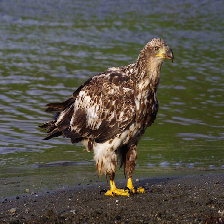

In [55]:
import tensorflow as tf # Import tensorflow
from keras.preprocessing import image
import numpy as np
import keras

# Mobile net input shape is (224,224)
img = image.load_img('/content/eagle.jpg',
                     target_size=(224, 224))
img


**Step-2: Read the MobileNet model**

In [56]:
mobile = keras.applications.mobilenet.MobileNet()

**Step-3: Read the classes**

In [57]:
# Load ImageNet class names
class_names_path = tf.keras.utils.get_file('ImageNetLabels.txt',
                                           'https://storage.googleapis.com/download.tensorflow.org/data/ImageNetLabels.txt')
with open(class_names_path, 'r') as f:
    class_names = f.read().splitlines()

# Print the class names
print("Class names:", class_names)

Class names: ['background', 'tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich', 'brambling', 'goldfinch', 'house finch', 'junco', 'indigo bunting', 'robin', 'bulbul', 'jay', 'magpie', 'chickadee', 'water ouzel', 'kite', 'bald eagle', 'vulture', 'great grey owl', 'European fire salamander', 'common newt', 'eft', 'spotted salamander', 'axolotl', 'bullfrog', 'tree frog', 'tailed frog', 'loggerhead', 'leatherback turtle', 'mud turtle', 'terrapin', 'box turtle', 'banded gecko', 'common iguana', 'American chameleon', 'whiptail', 'agama', 'frilled lizard', 'alligator lizard', 'Gila monster', 'green lizard', 'African chameleon', 'Komodo dragon', 'African crocodile', 'American alligator', 'triceratops', 'thunder snake', 'ringneck snake', 'hognose snake', 'green snake', 'king snake', 'garter snake', 'water snake', 'vine snake', 'night snake', 'boa constrictor', 'rock python', 'Indian cobra', 'green mamba', 'sea snake', 'hor

**Step-4: Check the shape and convert according to that**

In [58]:
mobile.input_shape

(None, 224, 224, 3)

- The Mobile net input shape is: (None,224,224,3)

- It is 4 dimensions data

- So we need to convert 3D to 4D

**Convert image to data**

In [59]:
img_array = image.img_to_array(img)
img_array.shape

(224, 224, 3)

In [60]:
img_array_expanded_dims = np.expand_dims(img_array, axis=0)
img_array_expanded_dims.shape

(1, 224, 224, 3)

**Step-5:Pass the image**

**Pass image to mobilenet**

In [61]:
preprocess_img=keras.applications.mobilenet.preprocess_input(img_array_expanded_dims)
preprocess_img.shape

(1, 224, 224, 3)

**Step-6:Predictions**

**Predictions**

In [62]:
predictions = mobile.predict(preprocess_img)
predictions.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 688ms/step


(1, 1000)

In [63]:
len(class_names)

1001

In [64]:
ID=np.argmax(predictions)

In [65]:
class_names[ID+1]

'bald eagle'

**Decode Predictions**

- Pass the classes probability arrat into the keras

- It will give top 5 predictions

In [66]:
from keras.applications import imagenet_utils
results = imagenet_utils.decode_predictions(predictions)
results

[[('n01614925', 'bald_eagle', np.float32(0.4400682)),
  ('n02025239', 'ruddy_turnstone', np.float32(0.3952669)),
  ('n01514859', 'hen', np.float32(0.07431153)),
  ('n01608432', 'kite', np.float32(0.051198065)),
  ('n01514668', 'cock', np.float32(0.009531561))]]

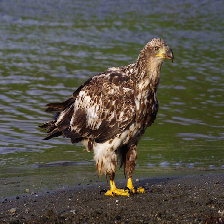

In [67]:
img